# Support Vector Machines (SVM)
**Tarea 1 – Investigación en Grupo | Módulo: DEVOPS E INTELIGENCIA ARTIFICIAL**

---

## 1. Descripción del Algoritmo

**Support Vector Machines (SVM)** es un algoritmo de aprendizaje supervisado desarrollado por **Vladimir Vapnik y Alexey Chervonenkis** en los años 60, con su forma moderna presentada por **Cortes y Vapnik en 1995**.

La idea central de SVM es encontrar el **hiperplano óptimo** que separa las clases con el **margen máximo** posible. Un hiperplano es simplemente una línea (en 2D), un plano (en 3D) o su equivalente en dimensiones más altas.

### Conceptos clave:
- **Hiperplano**: La frontera de decisión que separa las clases
- **Margen**: La distancia entre el hiperplano y los puntos más cercanos de cada clase
- **Vectores de Soporte**: Los puntos de entrenamiento más cercanos al hiperplano — son los únicos que importan para definirlo
- **Kernel Trick**: Técnica para separar datos que no son linealmente separables, proyectándolos a una dimensión mayor

### Analogía simple:
Imagina dos grupos de personas en una sala. SVM encuentra el pasillo más ancho posible que los separa. Las personas paradas justo en los bordes del pasillo son los 'vectores de soporte'.

## 2. Publicación que Propuso el Algoritmo (BibTeX y Referencias)

### BibTeX Original — SVM
```bibtex
@article{cortes1995support,
  title   = {Support-vector networks},
  author  = {Cortes, Corinna and Vapnik, Vladimir},
  journal = {Machine Learning},
  volume  = {20},
  number  = {3},
  pages   = {273--297},
  year    = {1995},
  publisher = {Springer}
}
```

### BibTeX — Kernel Methods
```bibtex
@book{vapnik1998statistical,
  title     = {Statistical Learning Theory},
  author    = {Vapnik, Vladimir N.},
  year      = {1998},
  publisher = {Wiley-Interscience},
  address   = {New York}
}
```

### Referencias APA
- Cortes, C., & Vapnik, V. (1995). Support-vector networks. *Machine Learning, 20*(3), 273–297.
- Vapnik, V. N. (1998). *Statistical Learning Theory*. Wiley-Interscience.

## 3. Tipo de Modelo

| Dimensión | Clasificación |
|---|---|
| **Método de Aprendizaje** | Aprendizaje Supervisado — Clasificación y Regresión (SVR) |
| **Por Parámetros** | No Paramétrico — el número de parámetros crece con los datos |
| **Datos de Aprendizaje** | Offline / Batch — se entrena con todo el conjunto a la vez |
| **Resultado del Entrenamiento** | Basado en Modelo — genera un hiperplano matemático como frontera |

## 4. Algoritmo de Entrenamiento

SVM resuelve un problema de **optimización** que maximiza el margen entre clases.

### Ecuación del hiperplano:
$$\mathbf{w} \cdot \mathbf{x} + b = 0$$

### Objetivo — Maximizar el margen:
$$\text{Maximizar } \frac{2}{||\mathbf{w}||}  \quad \text{equivalente a} \quad \text{Minimizar } \frac{1}{2}||\mathbf{w}||^2$$

### Kernels disponibles (para datos no lineales):

| Kernel | Fórmula | Cuándo usarlo |
|---|---|---|
| **Lineal** | $K(x,z) = x \cdot z$ | Datos linealmente separables |
| **Polinomial** | $K(x,z) = (x \cdot z + c)^d$ | Relaciones polinomiales |
| **RBF (Gaussiano)** | $K(x,z) = e^{-\gamma||x-z||^2}$ | Más usado — datos complejos |
| **Sigmoide** | $K(x,z) = \tanh(\alpha x \cdot z + c)$ | Similar a redes neuronales |

## 5. Tipos de Entrada

- **Variables numéricas** (continuas o discretas) — requiere normalización previa
- **Variables categóricas** convertidas a numéricas (One-Hot Encoding)
- **Texto** convertido a vectores numéricos (TF-IDF, Word2Vec)
- **Imágenes** convertidas a vectores de píxeles
- **Importante**: SVM es muy sensible a la escala → siempre normalizar los datos

## 6. Casos de Uso

| Área | Aplicación |
|---|---|
| 🖼️ Visión por computadora | Clasificación de imágenes, reconocimiento facial |
| 📧 Text mining | Clasificación de texto, detección de spam |
| 💳 Finanzas | Detección de fraude, scoring crediticio (Easy Shark usa SVM) |
| 🧬 Bioinformática | Clasificación de proteínas, diagnóstico de cáncer |
| 🎙️ Audio | Reconocimiento de voz y sonidos |
| 🌿 Agricultura | Clasificación de tipos de cultivos por imágenes satelitales |

## 7. Supuestos y Restricciones

### Supuestos:
- Las clases son separables (linealmente o mediante un kernel)
- Los datos están normalizados antes del entrenamiento
- El parámetro C (regularización) está bien calibrado

### Restricciones:
- **Lento con datasets grandes**: el entrenamiento escala mal con millones de datos
- **Sensible a la escala**: variables con rangos distintos afectan el resultado
- **Difícil de interpretar**: no genera reglas legibles como C4.5
- **Selección de kernel**: elegir el kernel incorrecto puede arruinar el modelo
- **Parámetros C y γ**: requieren ajuste cuidadoso (Grid Search / Cross Validation)

## 8. Source Code — Implementación en Python

In [ ]:
# ============================================================
# PASO 1: Importar librerías
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.svm import SVC
from sklearn.datasets import load_iris, make_circles, make_classification
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import seaborn as sns

print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


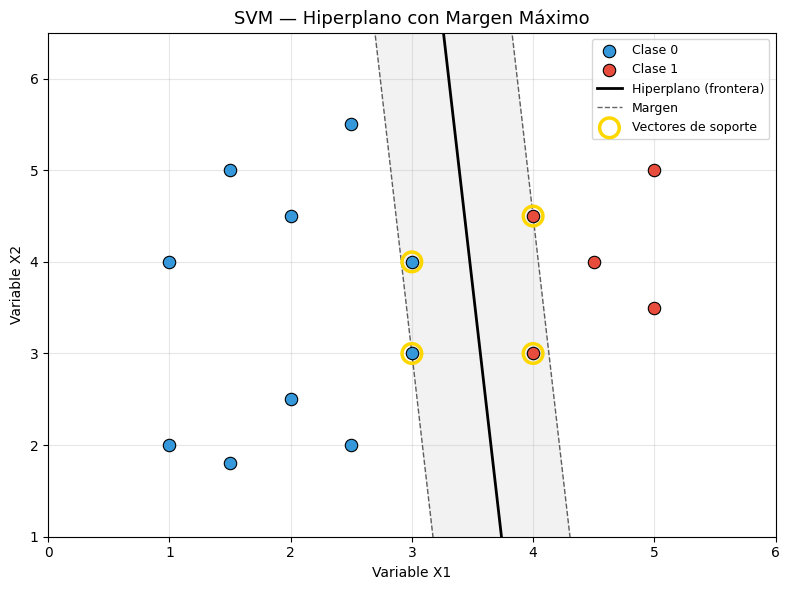

 Vectores de soporte encontrados: 4


In [ ]:
# ============================================================
# PASO 2: Visualizar el concepto del margen máximo
# El corazón de SVM: encontrar el hiperplano con mayor margen
# ============================================================
np.random.seed(42)

# Datos linealmente separables (2 clases)
X_demo = np.array([
    [1,2],[1.5,1.8],[2,2.5],[2.5,2],[3,3],
    [4,3],[4.5,4],[5,3.5],[4,4.5],[5,5],
    [1,4],[1.5,5],[2,4.5],[2.5,5.5],[3,4]
])
y_demo = np.array([0,0,0,0,0, 1,1,1,1,1, 0,0,0,0,0])

# Entrenar SVM lineal
svm_demo = SVC(kernel='linear', C=1.0)
svm_demo.fit(X_demo, y_demo)

# Graficar
fig, ax = plt.subplots(figsize=(8,6))

colores = ['#3498db', '#e74c3c']
for clase, color in zip([0,1], colores):
    mask = y_demo == clase
    ax.scatter(X_demo[mask,0], X_demo[mask,1], c=color, s=80,
               edgecolors='black', linewidth=0.8,
               label=f'Clase {clase}', zorder=3)

# Dibujar hiperplano y márgenes
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(0, 6, 50)
w = svm_demo.coef_[0]
b = svm_demo.intercept_[0]
yy = (-w[0]*xx - b) / w[1]
margin = 1 / np.sqrt(np.sum(w**2))
yy_pos = yy + margin * np.sqrt(1 + (w[0]/w[1])**2)
yy_neg = yy - margin * np.sqrt(1 + (w[0]/w[1])**2)

ax.plot(xx, yy, 'k-', linewidth=2, label='Hiperplano (frontera)')
ax.plot(xx, yy_pos, 'k--', linewidth=1, alpha=0.6, label='Margen')
ax.plot(xx, yy_neg, 'k--', linewidth=1, alpha=0.6)
ax.fill_between(xx, yy_pos, yy_neg, alpha=0.1, color='gray')

# Resaltar vectores de soporte
sv = svm_demo.support_vectors_
ax.scatter(sv[:,0], sv[:,1], s=200, facecolors='none',
           edgecolors='gold', linewidth=2.5, zorder=4, label='Vectores de soporte')

ax.set_xlim(0, 6)
ax.set_ylim(1, 6.5)
ax.set_title('SVM — Hiperplano con Margen Máximo', fontsize=13)
ax.legend(fontsize=9)
ax.set_xlabel('Variable X1')
ax.set_ylabel('Variable X2')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
print(f' Vectores de soporte encontrados: {len(sv)}')

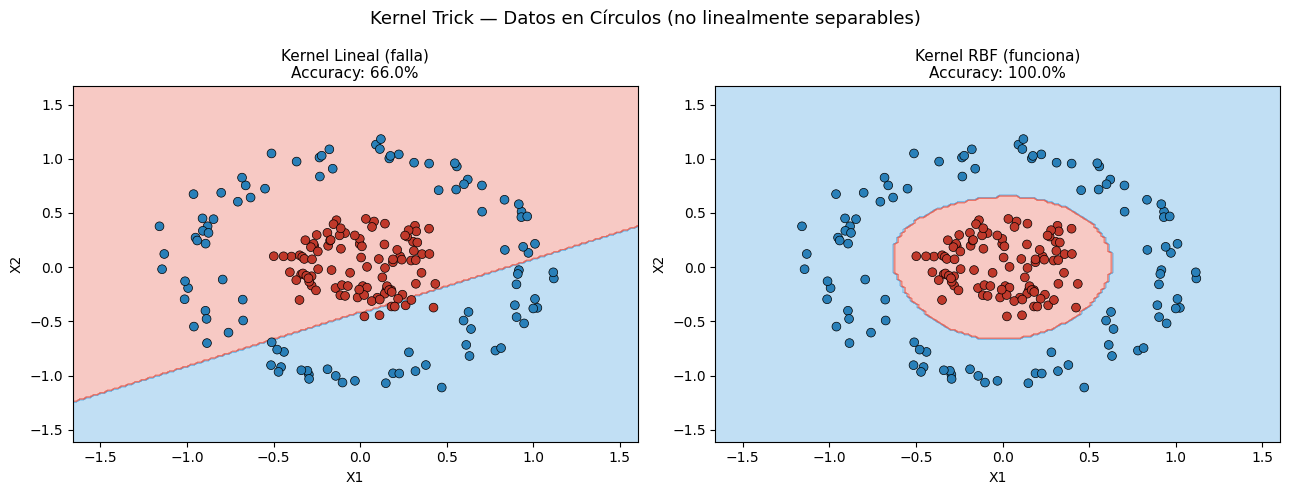

 El Kernel RBF proyecta los datos a mayor dimensión donde sí son separables


In [ ]:
# ============================================================
# PASO 3: Kernel Trick — datos que NO son linealmente separables
# El kernel RBF proyecta los datos a mayor dimensión
# ============================================================
X_circles, y_circles = make_circles(n_samples=200, noise=0.1, factor=0.3, random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# SVM Lineal (NO funciona bien)
svm_lin = SVC(kernel='linear', C=1.0)
svm_lin.fit(X_circles, y_circles)
acc_lin = accuracy_score(y_circles, svm_lin.predict(X_circles))

# SVM RBF (SÍ funciona)
svm_rbf = SVC(kernel='rbf', C=1.0, gamma='scale')
svm_rbf.fit(X_circles, y_circles)
acc_rbf = accuracy_score(y_circles, svm_rbf.predict(X_circles))

def plot_decision_boundary(model, X, y, ax, title, acc):
    h = 0.02
    x_min, x_max = X[:,0].min()-0.5, X[:,0].max()+0.5
    y_min, y_max = X[:,1].min()-0.5, X[:,1].max()+0.5
    xx, yy = np.meshgrid(np.arange(x_min,x_max,h), np.arange(y_min,y_max,h))
    Z = model.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=ListedColormap(['#3498db','#e74c3c']))
    ax.scatter(X[:,0], X[:,1], c=y, cmap=ListedColormap(['#2980b9','#c0392b']),
               edgecolors='black', linewidth=0.5, s=40)
    ax.set_title(f'{title}\nAccuracy: {acc*100:.1f}%', fontsize=11)
    ax.set_xlabel('X1')
    ax.set_ylabel('X2')

plot_decision_boundary(svm_lin, X_circles, y_circles, axes[0], 'Kernel Lineal (falla)', acc_lin)
plot_decision_boundary(svm_rbf, X_circles, y_circles, axes[1], 'Kernel RBF (funciona)', acc_rbf)

plt.suptitle('Kernel Trick — Datos en Círculos (no linealmente separables)', fontsize=13)
plt.tight_layout()
plt.show()
print(' El Kernel RBF proyecta los datos a mayor dimensión donde sí son separables')

In [ ]:
# ============================================================
# PASO 4: SVM con dataset Iris — clasificación real
# ============================================================
iris = load_iris()
X = iris.data
y = iris.target

# Dividir datos
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# IMPORTANTE: Normalizar — SVM es muy sensible a la escala
scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

# Entrenar SVM
svm_iris = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)
svm_iris.fit(X_train_s, y_train)

y_pred = svm_iris.predict(X_test_s)

print(' Accuracy SVM:', round(accuracy_score(y_test, y_pred)*100, 2), '%')
print()
print(' Reporte de Clasificación:')
print(classification_report(y_test, y_pred, target_names=iris.target_names))
print(f' Vectores de soporte por clase: {svm_iris.n_support_}')

 Accuracy SVM: 93.33 %

 Reporte de Clasificación:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        15
  versicolor       0.88      0.93      0.90        15
   virginica       0.93      0.87      0.90        15

    accuracy                           0.93        45
   macro avg       0.93      0.93      0.93        45
weighted avg       0.93      0.93      0.93        45

 Vectores de soporte por clase: [ 6 18 16]


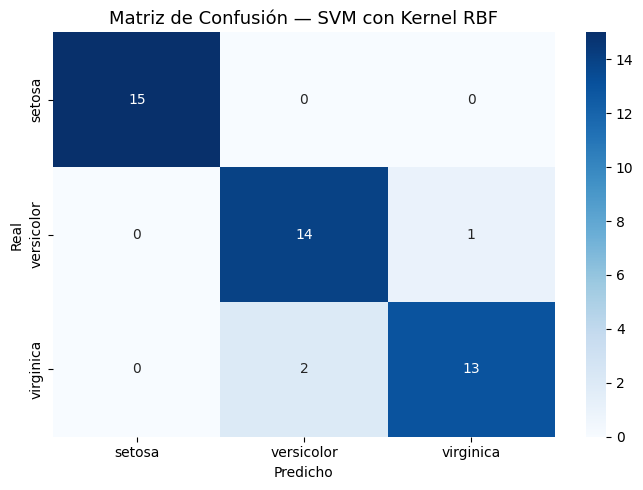

In [ ]:
# ============================================================
# PASO 5: Matriz de Confusión
# ============================================================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=iris.target_names,
            yticklabels=iris.target_names)
plt.title('Matriz de Confusión — SVM con Kernel RBF', fontsize=13)
plt.ylabel('Real')
plt.xlabel('Predicho')
plt.tight_layout()
plt.show()

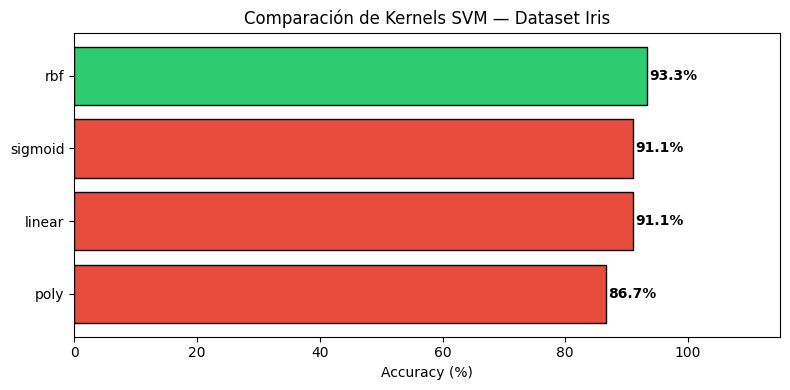

 Kernel  Accuracy
   poly 86.666667
 linear 91.111111
sigmoid 91.111111
    rbf 93.333333


In [ ]:
# ============================================================
# PASO 6: Comparación de Kernels
# ============================================================
kernels = ['linear', 'poly', 'rbf', 'sigmoid']
resultados = []

for k in kernels:
    modelo = SVC(kernel=k, C=1.0, gamma='scale', random_state=42)
    modelo.fit(X_train_s, y_train)
    acc = accuracy_score(y_test, modelo.predict(X_test_s))
    resultados.append({'Kernel': k, 'Accuracy': acc*100})

df_res = pd.DataFrame(resultados).sort_values('Accuracy', ascending=True)

plt.figure(figsize=(8, 4))
colores_bar = ['#e74c3c' if k != 'rbf' else '#2ecc71' for k in df_res['Kernel']]
bars = plt.barh(df_res['Kernel'], df_res['Accuracy'], color=colores_bar, edgecolor='black')
for bar, val in zip(bars, df_res['Accuracy']):
    plt.text(bar.get_width()+0.3, bar.get_y()+bar.get_height()/2,
             f'{val:.1f}%', va='center', fontweight='bold')
plt.xlim(0, 115)
plt.title('Comparación de Kernels SVM — Dataset Iris', fontsize=12)
plt.xlabel('Accuracy (%)')
plt.tight_layout()
plt.show()
print(df_res.to_string(index=False))

In [ ]:
# ============================================================
# PASO 7: Predicción con nuevos datos
# ============================================================
nueva_muestra = np.array([[5.1, 3.5, 1.4, 0.2]])  # Probablemente setosa
nueva_norm = scaler.transform(nueva_muestra)  # Normalizar con el mismo scaler

prediccion = svm_iris.predict(nueva_norm)
print(f' Predicción SVM: {iris.target_names[prediccion[0]]}')
print(f' Número de vectores de soporte usados: {sum(svm_iris.n_support_)}')

 Predicción SVM: setosa
 Número de vectores de soporte usados: 40


## 9. Conclusiones

- **SVM** es uno de los algoritmos más poderosos para clasificación, especialmente con datos de **alta dimensión**.
- El **Kernel Trick** es su característica más importante — permite separar datos complejos sin calcular explícitamente la transformación.
- Es muy usado en **finanzas** (scoring crediticio), **medicina** (diagnóstico) y **visión por computadora**.
- Su principal limitación es el **costo computacional** con datasets muy grandes y la **dificultad de interpretación**.
- A diferencia de C4.5, SVM **no genera reglas legibles** — es una 'caja negra' matemática, lo que puede ser un problema en contextos regulados.